In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv('telecom_customer_churn_realistic_100k.csv')

In [4]:
df.head(3)

,Customer_ID,Gender,Age,Senior_Citizen,Marital_Status,Region,Tenure,Contract_Type,Internet_Service,Phone_Service,...,Monthly_Charges,Total_Charges,Data_Usage_GB,Call_Minutes,Support_Tickets,Satisfaction_Score,Last_Login_Days,Late_Payments,Auto_Pay,Churn
0,CUST000001,Male,39,Yes,Divorced,South,7,Two Year,NaN,Yes,...,844.67,5750.17,45.2,355,0,6.0,8,0,No,Yes
1,CUST000002,Female,33,Yes,Divorced,North,10,Month-to-Month,Fiber,Yes,...,891.31,9044.86,238.8,219,1,7.0,9,2,Yes,No
2,CUST000003,Male,59,Yes,Married,West,18,Two Year,5G,Yes,...,1097.05,19857.30,196.8,248,0,5.0,36,0,No,No


In [5]:
df.isnull().sum()

Customer_ID               0
Gender                    0
Age                       0
Senior_Citizen            0
Marital_Status            0
Region                    0
Tenure                    0
Contract_Type             0
Internet_Service      25047
Phone_Service             0
Multiple_Lines            0
Tech_Support           8065
Streaming_Service         0
Payment_Method         3083
Monthly_Charges        2046
Total_Charges          4981
Data_Usage_GB             0
Call_Minutes              0
Support_Tickets           0
Satisfaction_Score     4007
Last_Login_Days           0
Late_Payments             0
Auto_Pay                  0
Churn                     0
dtype: int64

In [6]:
df.columns

Index(['Customer_ID', 'Gender', 'Age', 'Senior_Citizen', 'Marital_Status',
       'Region', 'Tenure', 'Contract_Type', 'Internet_Service',
       'Phone_Service', 'Multiple_Lines', 'Tech_Support', 'Streaming_Service',
       'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Data_Usage_GB',
       'Call_Minutes', 'Support_Tickets', 'Satisfaction_Score',
       'Last_Login_Days', 'Late_Payments', 'Auto_Pay', 'Churn'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer_ID         100000 non-null  str    
 1   Gender              100000 non-null  str    
 2   Age                 100000 non-null  int64  
 3   Senior_Citizen      100000 non-null  str    
 4   Marital_Status      100000 non-null  str    
 5   Region              100000 non-null  str    
 6   Tenure              100000 non-null  int64  
 7   Contract_Type       100000 non-null  str    
 8   Internet_Service    74953 non-null   str    
 9   Phone_Service       100000 non-null  str    
 10  Multiple_Lines      100000 non-null  str    
 11  Tech_Support        91935 non-null   str    
 12  Streaming_Service   100000 non-null  str    
 13  Payment_Method      96917 non-null   str    
 14  Monthly_Charges     97954 non-null   float64
 15  Total_Charges       95019 non-null   float64
 

## In Data Analysis What All thing We Do

1.Missing Values

2.Explore About the Numerical Variables

3.Explore About categorical Variables

4.Finding Relationship between features

In [8]:
null_values = [feature for feature in df.columns if df[feature].isnull().sum() > 0]

In [10]:
for feature in null_values:
    print(feature, np.round(df[feature].isnull().mean(), 4),  ' % missing values')

Internet_Service 0.2505  % missing values
Tech_Support 0.0806  % missing values
Payment_Method 0.0308  % missing values
Monthly_Charges 0.0205  % missing values
Total_Charges 0.0498  % missing values
Satisfaction_Score 0.0401  % missing values


## Observation:
In this data we have a many missing values and we have need to find a relationship

In [15]:
df['Churn'].unique()

df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

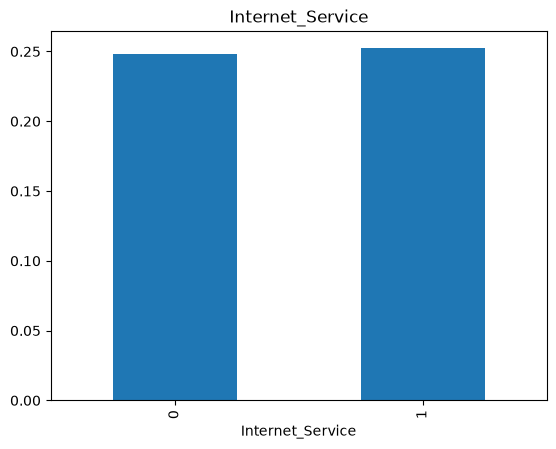

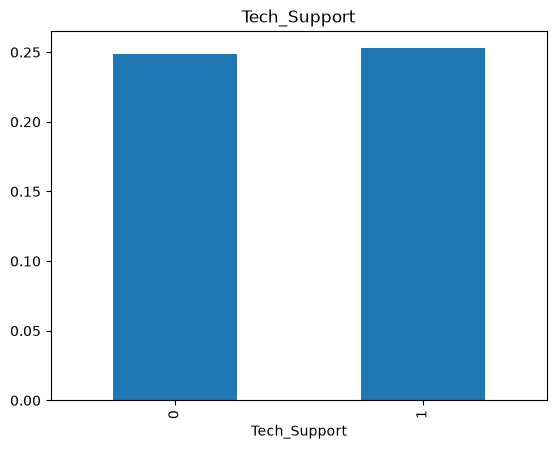

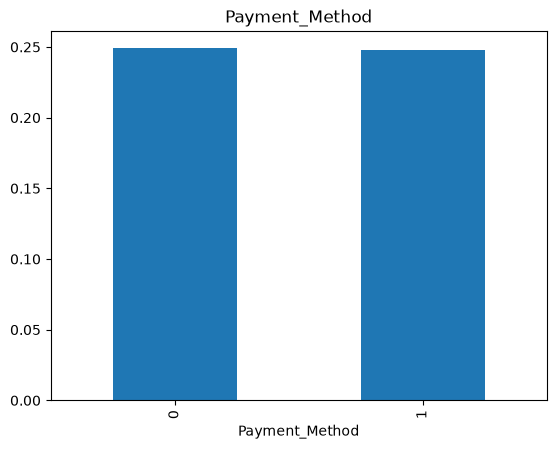

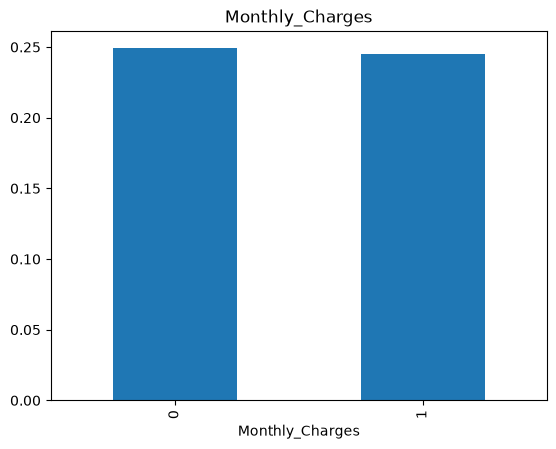

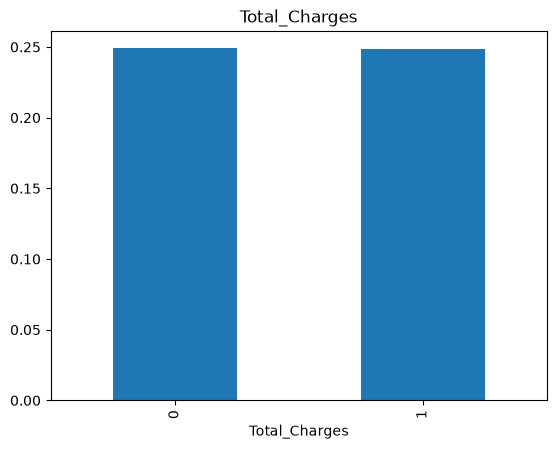

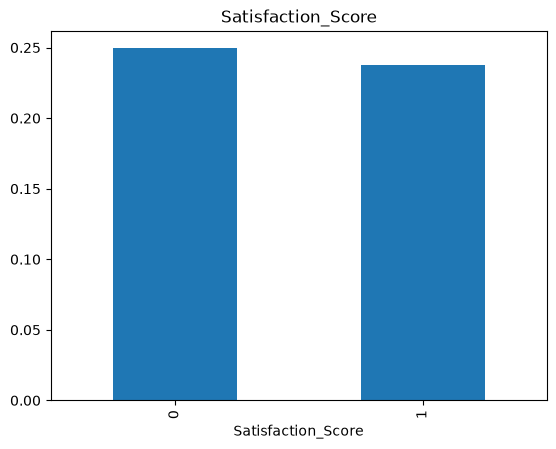

In [18]:
for feature in null_values:
    data = df.copy()

    data[feature] = np.where(data[feature].isnull(),1,0)

    data.groupby(feature)['Churn'].mean().plot.bar()
    plt.title(feature)
    plt.show()

Here With  the relation between the missing values and the dependent variable is clearly visible.So We need to replace these nan values with something meaningful which we will do in the Feature Engineering section

### Numerical Variables

In [31]:
numerical_features = df.select_dtypes(include='number').columns.tolist()

print(numerical_features)

['Age', 'Tenure', 'Monthly_Charges', 'Total_Charges', 'Data_Usage_GB', 'Call_Minutes', 'Support_Tickets', 'Satisfaction_Score', 'Last_Login_Days', 'Late_Payments', 'Churn']


In [33]:
target = 'Churn'

numerical_features = (
    df.select_dtypes(include='number')
      .columns
      .drop(target)
      .tolist()
)

print(numerical_features)

df[numerical_features].describe().T

['Age', 'Tenure', 'Monthly_Charges', 'Total_Charges', 'Data_Usage_GB', 'Call_Minutes', 'Support_Tickets', 'Satisfaction_Score', 'Last_Login_Days', 'Late_Payments']


,count,mean,std,min,25%,50%,75%,max
Age,100000.0,41.815470,13.438159,18.00,32.00,42.000,51.0000,106.00
Tenure,100000.0,23.525790,24.134516,0.00,6.00,16.000,33.0000,255.00
Monthly_Charges,97954.0,900.977265,319.197993,99.00,684.26,900.345,1115.9975,2195.64
Total_Charges,95019.0,21198.605007,24243.433382,-89.62,4987.22,13150.380,28597.1200,367024.79
Data_Usage_GB,100000.0,180.686837,88.214063,0.00,119.10,180.100,240.5000,575.80
Call_Minutes,100000.0,351.741690,175.682534,0.00,228.00,350.000,472.0000,1111.00
Support_Tickets,100000.0,1.547930,1.986122,0.00,0.00,1.000,2.0000,22.00
Satisfaction_Score,95993.0,6.472993,1.952244,1.00,5.00,6.000,8.0000,10.00
Last_Login_Days,100000.0,14.593360,15.111556,0.00,4.00,10.000,20.0000,170.00
Late_Payments,100000.0,0.769450,1.166272,0.00,0.00,0.000,1.0000,16.00


In [35]:
numerical_columns = df.select_dtypes(('int64','float64'))

In [36]:
numerical_columns.head(2)

,Age,Tenure,Monthly_Charges,Total_Charges,Data_Usage_GB,Call_Minutes,Support_Tickets,Satisfaction_Score,Last_Login_Days,Late_Payments,Churn
0,39,7,844.67,5750.17,45.2,355,0,6.0,8,0,1
1,33,10,891.31,9044.86,238.8,219,1,7.0,9,2,0


In [37]:
numerical_columns.isnull().sum()

Age                      0
Tenure                   0
Monthly_Charges       2046
Total_Charges         4981
Data_Usage_GB            0
Call_Minutes             0
Support_Tickets          0
Satisfaction_Score    4007
Last_Login_Days          0
Late_Payments            0
Churn                    0
dtype: int64

# EDA IN NUMERICAL COLUMNS

In [38]:
numerical_columns.head(2)

,Age,Tenure,Monthly_Charges,Total_Charges,Data_Usage_GB,Call_Minutes,Support_Tickets,Satisfaction_Score,Last_Login_Days,Late_Payments,Churn
0,39,7,844.67,5750.17,45.2,355,0,6.0,8,0,1
1,33,10,891.31,9044.86,238.8,219,1,7.0,9,2,0


## Checking Outliers

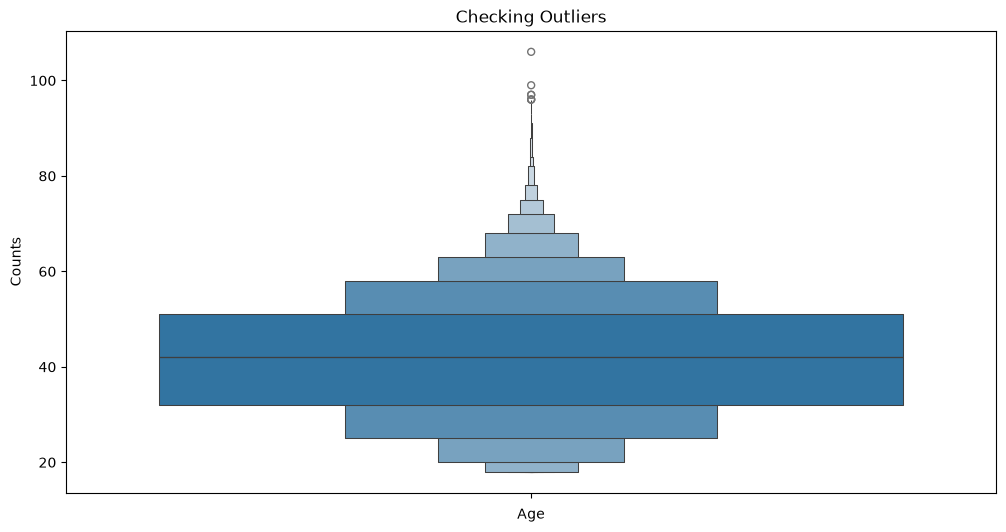

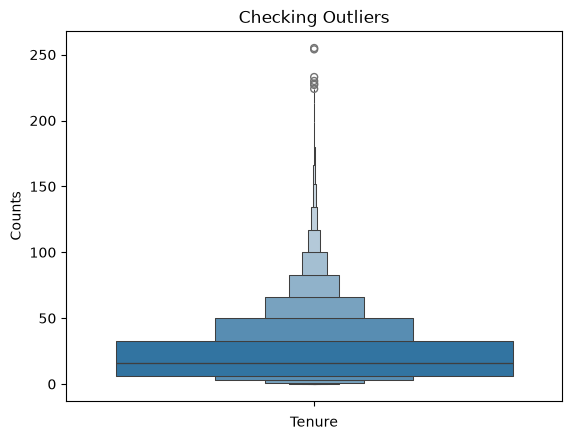

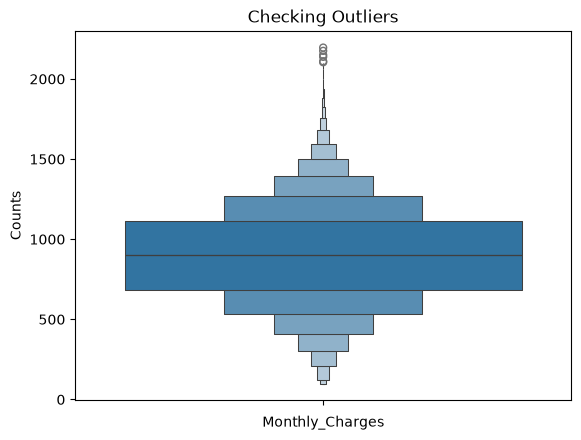

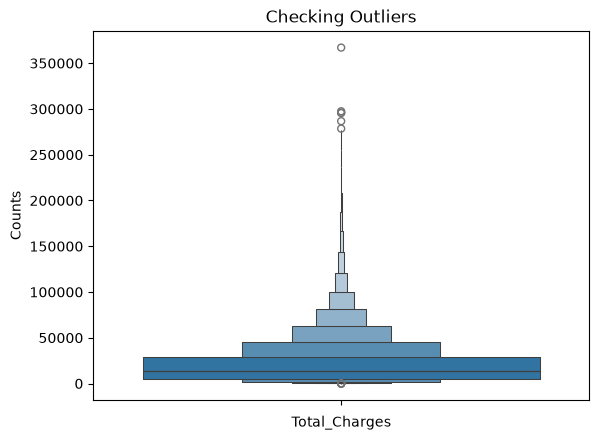

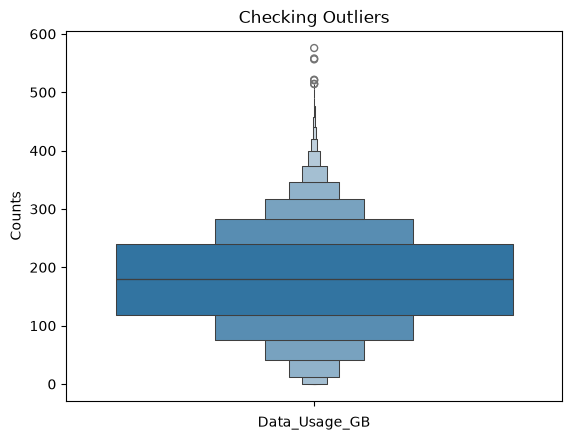

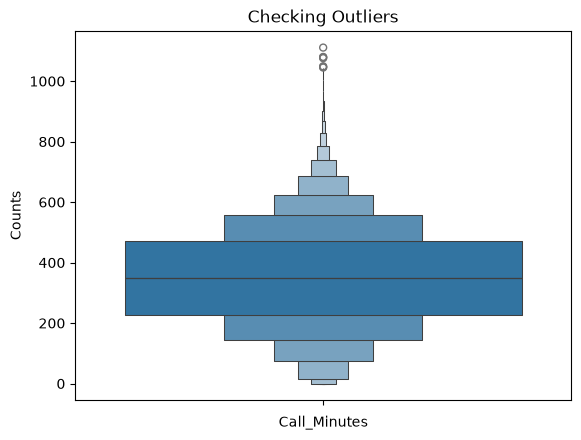

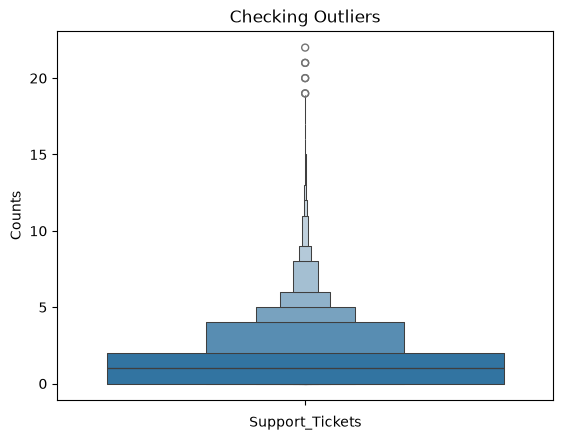

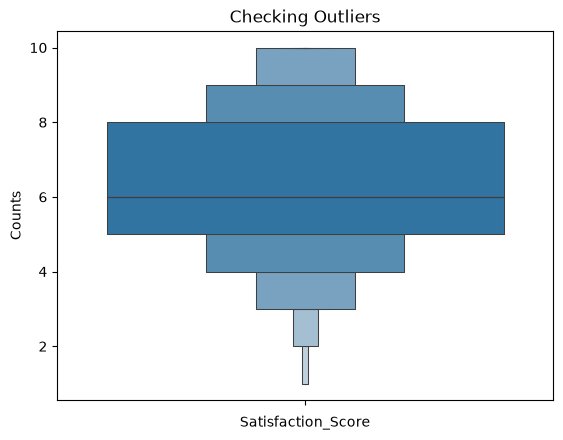

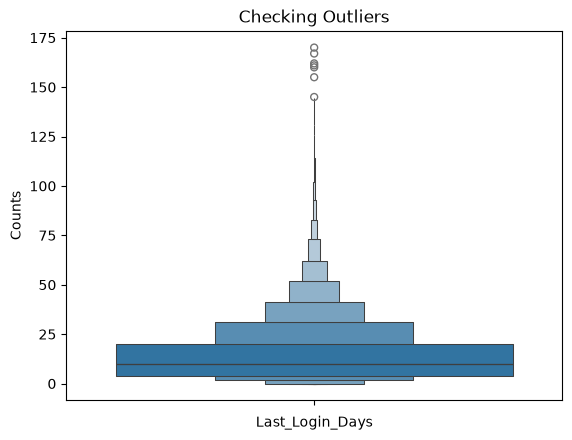

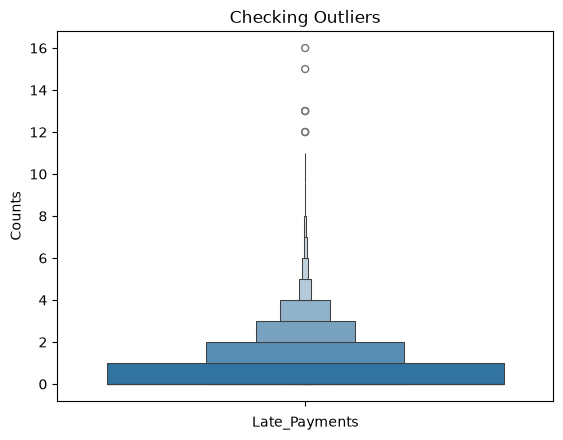

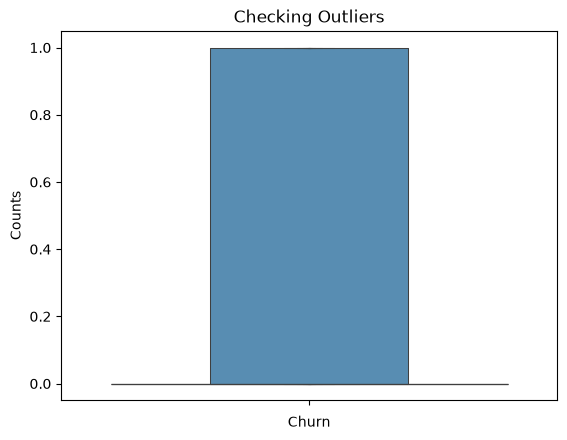

In [45]:
plt.figure(figsize=(12,6))
for i in numerical_columns:
    sns.boxenplot(df[i])
    plt.xlabel(i)
    plt.ylabel("Counts")
    plt.title("Checking Outliers")
    plt.show()
    

## Observation:
In this data we have a many outliers we have need to understand why outliers exist in this columns then we can take decition to drop a this outliers

# INCONSISTENT VALUES

In [46]:
for col in numerical_columns:
    print(f"\n--- {col} ---")
    print("Min:", df[col].min())
    print("Max:", df[col].max())
    print("Unique values:", df[col].nunique())


--- Age ---
Min: 18
Max: 106
Unique values: 82

--- Tenure ---
Min: 0
Max: 255
Unique values: 213

--- Monthly_Charges ---
Min: 99.0
Max: 2195.64
Unique values: 66236

--- Total_Charges ---
Min: -89.62
Max: 367024.79
Unique values: 93702

--- Data_Usage_GB ---
Min: 0.0
Max: 575.8
Unique values: 4446

--- Call_Minutes ---
Min: 0
Max: 1111
Unique values: 964

--- Support_Tickets ---
Min: 0
Max: 22
Unique values: 23

--- Satisfaction_Score ---
Min: 1.0
Max: 10.0
Unique values: 10

--- Last_Login_Days ---
Min: 0
Max: 170
Unique values: 140

--- Late_Payments ---
Min: 0
Max: 16
Unique values: 16

--- Churn ---
Min: 0
Max: 1
Unique values: 2


## Observation:
THE COLUMNS NAME IS Total_Charges IN THIS WE HAVE NEGATIVE VALUES WE NEDD TO UNDERSTAND WHY THE NEGATIVE VALUES EXISTS AND AFTER TAKE A DECISTION DROP THAT OR KEEP T

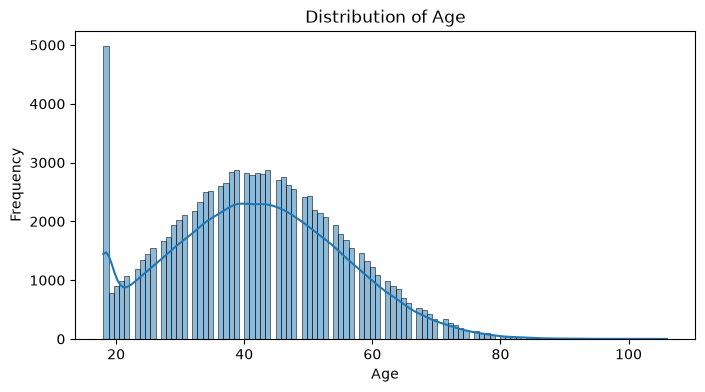

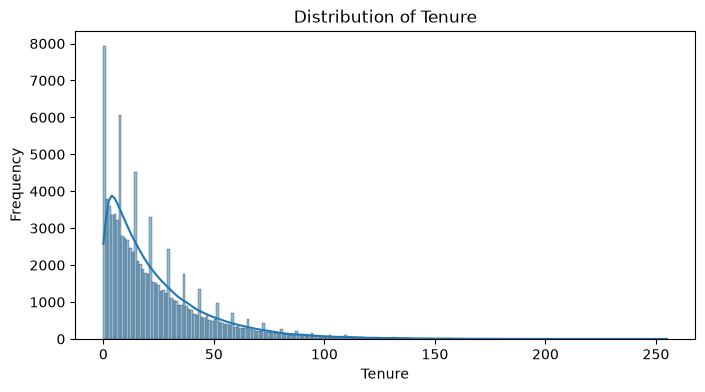

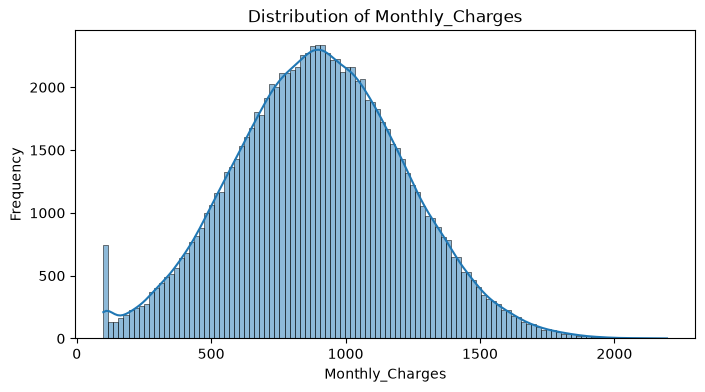

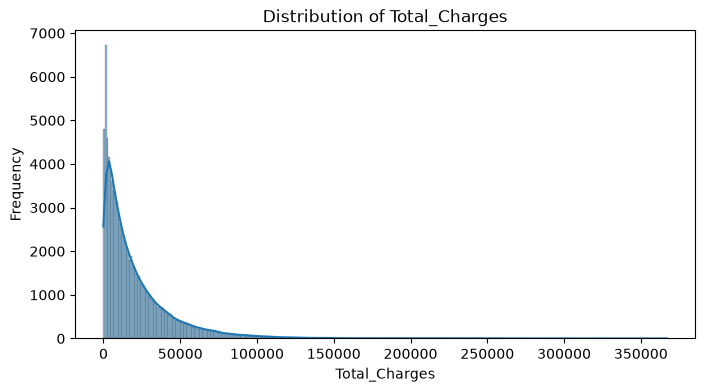

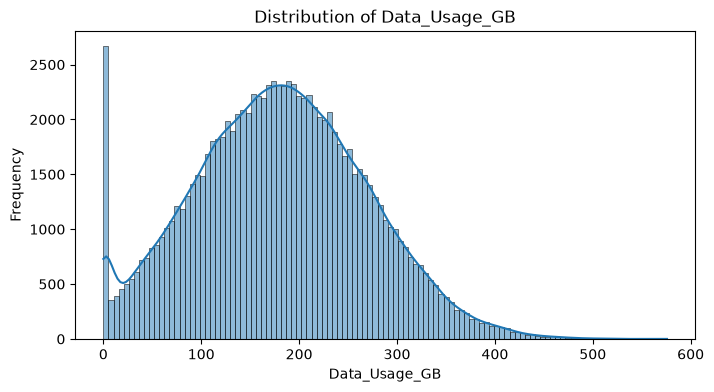

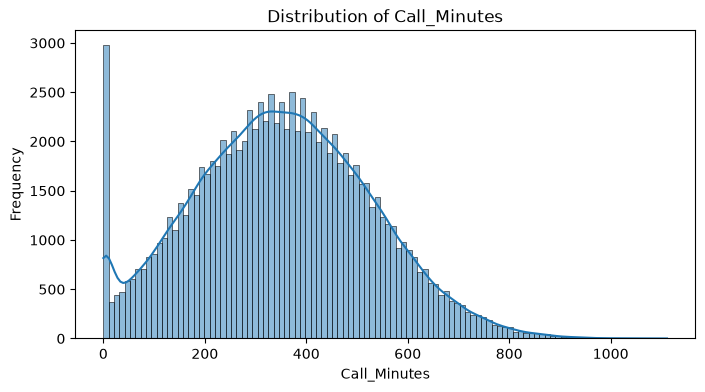

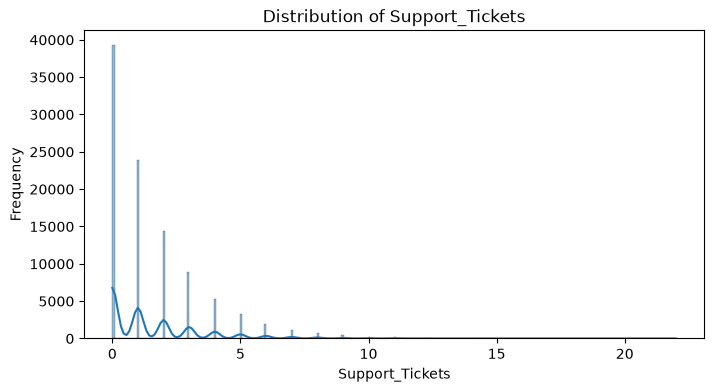

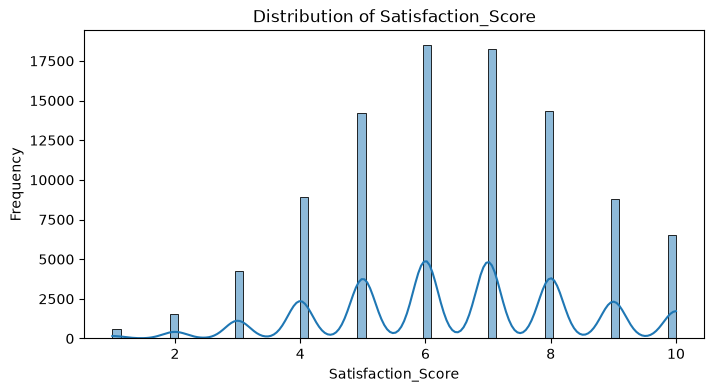

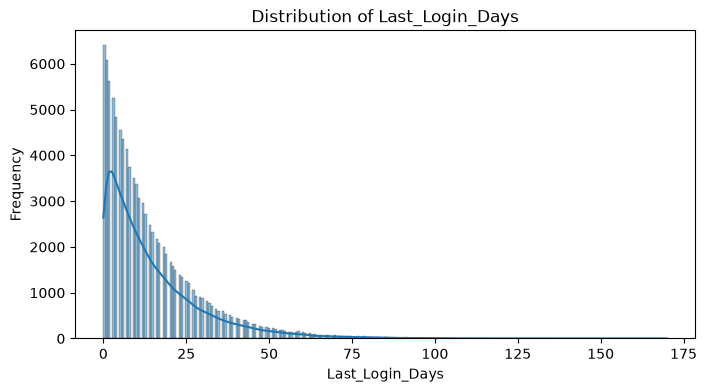

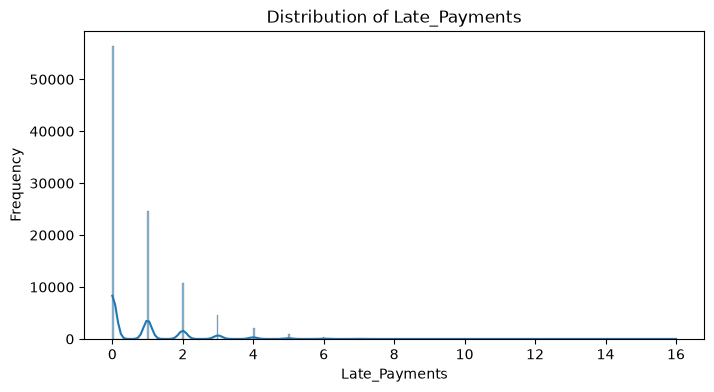

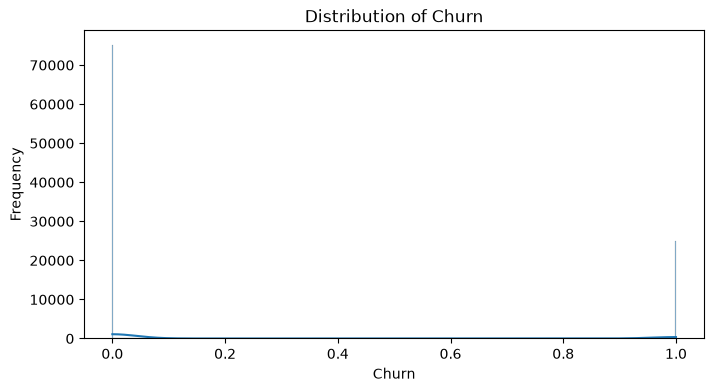

In [48]:
for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    
    sns.histplot(df[col].dropna(), kde=True)
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    plt.show()

## Observation:
ALMOST ALL COLUMSN NORMAL DISTRIBUTION

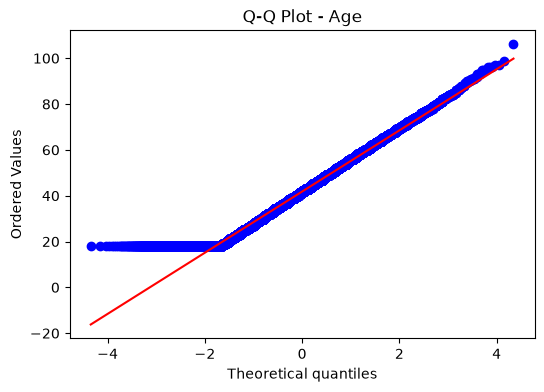

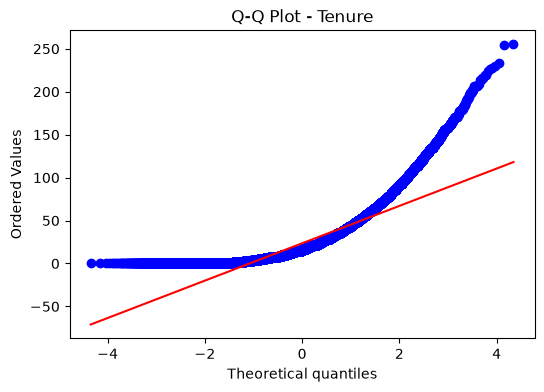

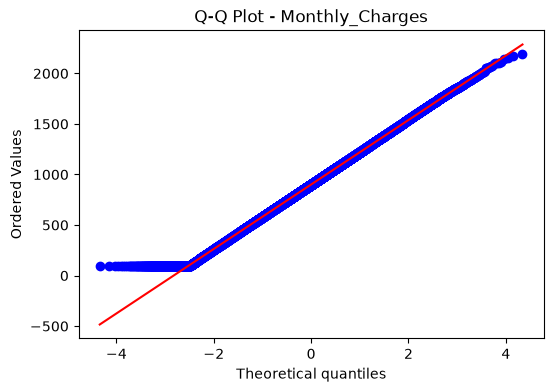

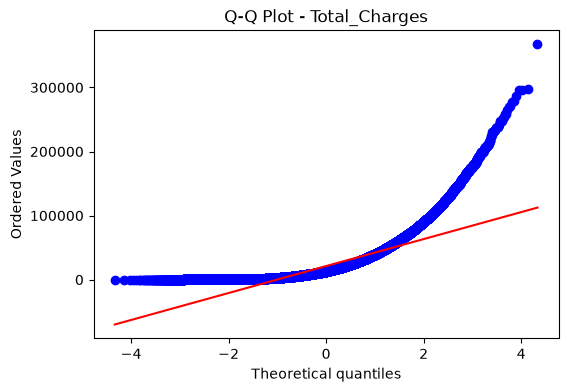

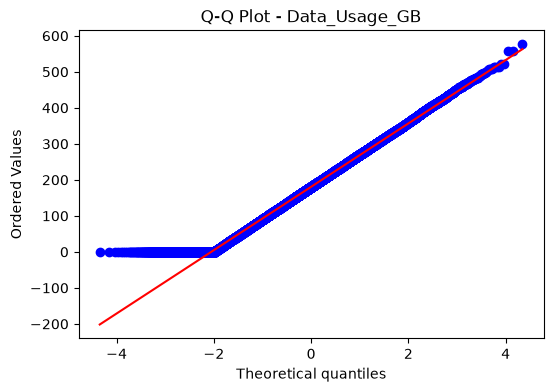

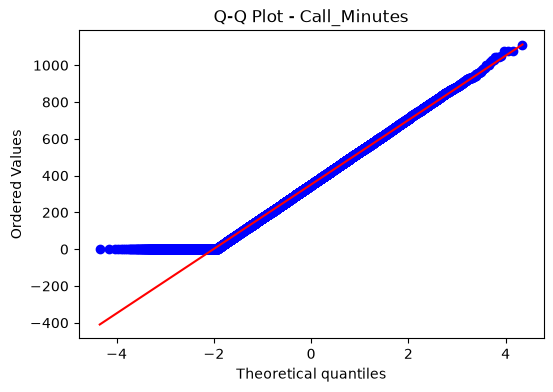

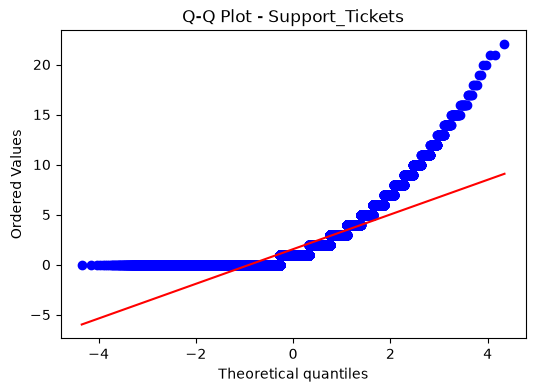

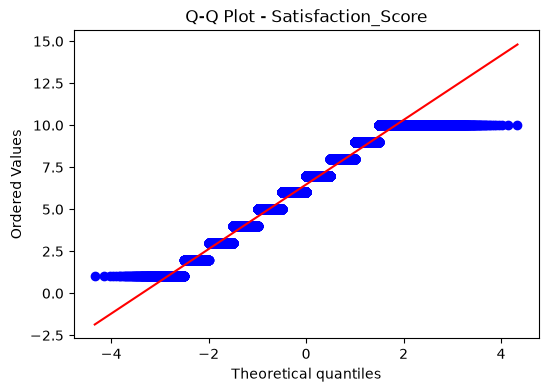

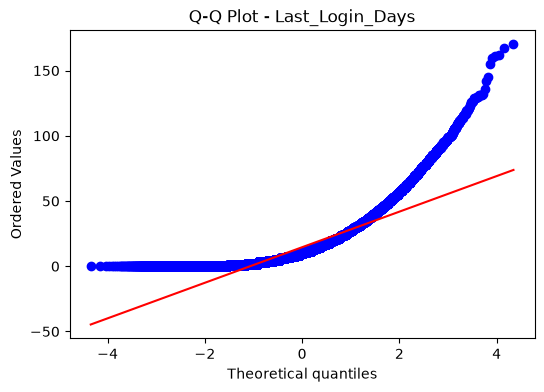

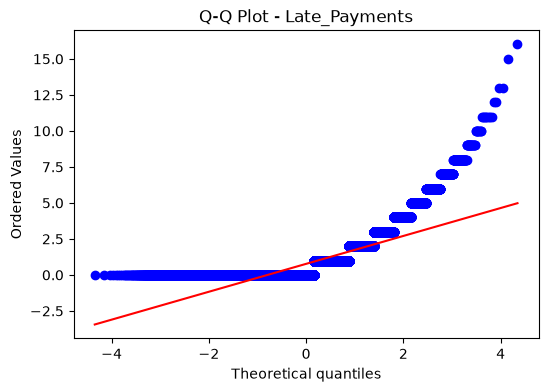

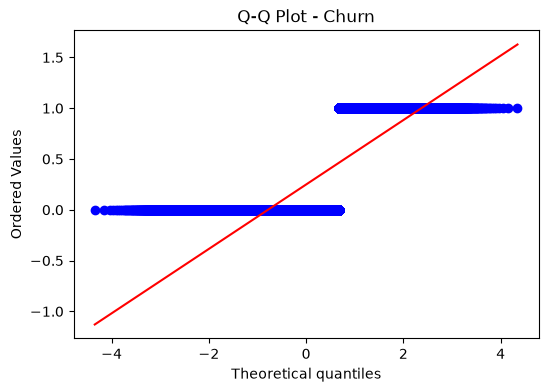

In [50]:
import scipy.stats as stats
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    
    plt.title(f'Q-Q Plot - {col}')
    plt.show()

## check skewness for all columns

In [51]:
for col in numerical_columns:
    print(f"{col}: {df[col].skew():.3f}")

Age: 0.209
Tenure: 2.003
Monthly_Charges: 0.044
Total_Charges: 2.571
Data_Usage_GB: 0.120
Call_Minutes: 0.138
Support_Tickets: 2.048
Satisfaction_Score: -0.163
Last_Login_Days: 1.998
Late_Payments: 2.187
Churn: 1.161


In [52]:
normality_summary = []

for col in numerical_columns:
    data = df[col].dropna()
    
    normality_summary.append({
        'Feature': col,
        'Mean': data.mean(),
        'Median': data.median(),
        'Std': data.std(),
        'Skewness': data.skew(),
        'Min': data.min(),
        'Max': data.max()
    })

normality_summary = pd.DataFrame(normality_summary)

normality_summary

,Feature,Mean,Median,Std,Skewness,Min,Max
0,Age,41.815470,42.000,13.438159,0.209434,18.00,106.00
1,Tenure,23.525790,16.000,24.134516,2.002961,0.00,255.00
2,Monthly_Charges,900.977265,900.345,319.197993,0.043840,99.00,2195.64
3,Total_Charges,21198.605007,13150.380,24243.433382,2.571436,-89.62,367024.79
4,Data_Usage_GB,180.686837,180.100,88.214063,0.120363,0.00,575.80
5,Call_Minutes,351.741690,350.000,175.682534,0.137765,0.00,1111.00
6,Support_Tickets,1.547930,1.000,1.986122,2.048301,0.00,22.00
7,Satisfaction_Score,6.472993,6.000,1.952244,-0.163270,1.00,10.00
8,Last_Login_Days,14.593360,10.000,15.111556,1.998016,0.00,170.00
9,Late_Payments,0.769450,0.000,1.166272,2.187279,0.00,16.00


### Observation – Distribution of Numerical Features

After analyzing the numerical features, we observed that **most of the numerical variables are not normally distributed**. Several features show noticeable **positive or negative skewness**, indicating that their values are not symmetrically distributed around the mean.

Some numerical features contain **extreme values and outliers**, which may be contributing to the observed skewness. In several columns, the mean and median also differ considerably, which is another indication of a non-symmetric distribution.

Therefore, the numerical features show a combination of **skewed and non-normal distributions** rather than following a perfect Gaussian distribution.

For further analysis, we should identify highly skewed features and investigate their outliers and possible transformations, such as **log transformation**, where appropriate. However, transformation will depend on the requirements of the machine learning algorithm being used.


 ## TO FIND USEFUL INSIGHT FOR NUMERICAL COLUMNS

In [54]:
numerical_columns.head(2)

,Age,Tenure,Monthly_Charges,Total_Charges,Data_Usage_GB,Call_Minutes,Support_Tickets,Satisfaction_Score,Last_Login_Days,Late_Payments,Churn
0,39,7,844.67,5750.17,45.2,355,0,6.0,8,0,1
1,33,10,891.31,9044.86,238.8,219,1,7.0,9,2,0


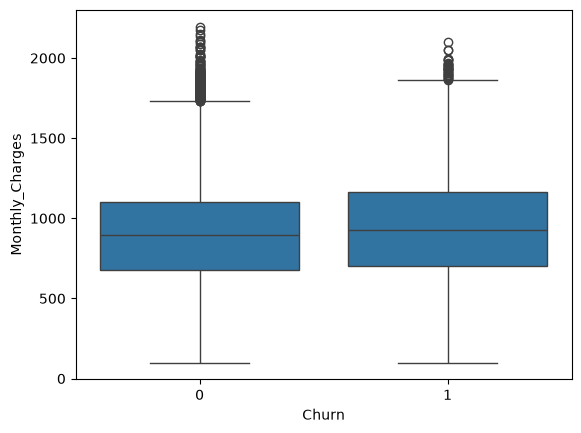

In [62]:
sns.boxplot(x='Churn', y='Monthly_Charges', data=df)
plt.show()

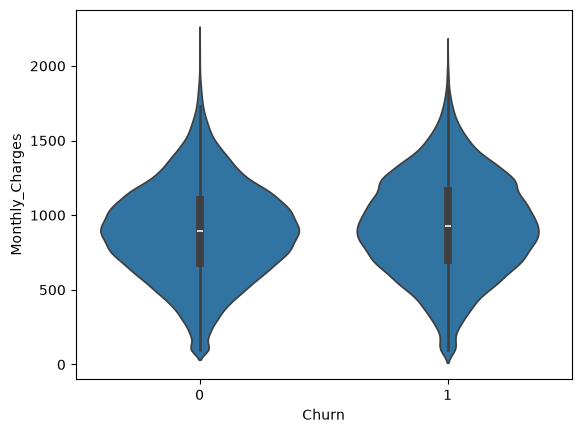

In [63]:
sns.violinplot(x='Churn', y='Monthly_Charges', data=df)
plt.show()

In [64]:
df.groupby('Churn')['Monthly_Charges'].agg(
    ['mean', 'median', 'std', 'min', 'max']
)

,mean,median,std,min,max
Churn,,,,,
0,891.873849,892.81,315.306331,99.0,2195.64
1,928.428577,925.98,329.141787,99.0,2098.36


## Observation:
Churned customers have slightly higher average and median Total Charges than non-churned customers in this dataset.

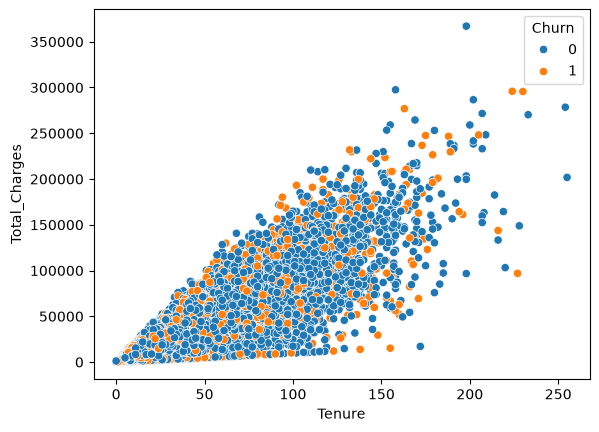

In [65]:
sns.scatterplot(
    data=df,
    x='Tenure',
    y='Total_Charges',
    hue='Churn'
)

plt.show()

In [66]:
numerical_columns.head(2)

,Age,Tenure,Monthly_Charges,Total_Charges,Data_Usage_GB,Call_Minutes,Support_Tickets,Satisfaction_Score,Last_Login_Days,Late_Payments,Churn
0,39,7,844.67,5750.17,45.2,355,0,6.0,8,0,1
1,33,10,891.31,9044.86,238.8,219,1,7.0,9,2,0


In [67]:
df.groupby('Churn')['Total_Charges'].agg(
    ['mean', 'median', 'std', 'min', 'max']
)

,mean,median,std,min,max
Churn,,,,,
0,21432.087373,13495.66,24137.449127,-89.62,367024.79
1,20494.338582,12069.63,24547.415425,-42.75,295869.53


### Observation – Total Charges vs Churn

The distribution of **Total Charges** is quite different across the two churn groups.

* Customers who **did not churn (Churn = 0)** have a slightly higher average Total Charges (**21,432**) compared with customers who churned (**20,494**).
* The median Total Charges is also higher for non-churned customers (**13,495.66**) compared with churned customers (**12,069.63**).
* The standard deviation is high for both groups, indicating **considerable variability** in Total Charges.
* Both groups contain negative Total Charges values, which are **not realistic** for a telecom billing feature and should be investigated as possible data-quality issues.
* The maximum values are very high compared with the median, suggesting that the feature is **strongly right-skewed and contains potential extreme outliers**.

Overall, customers who churned tend to have **slightly lower Total Charges** than customers who stayed. However, the difference in the mean and median is relatively small compared with the overall variation, so Total Charges alone may not be a strong indicator of churn.


In [68]:
df.groupby('Churn')['Call_Minutes'].agg(
    ['mean', 'median', 'std', 'min', 'max']
)

,mean,median,std,min,max
Churn,,,,,
0,351.771011,350.0,175.588348,0,1111
1,351.653237,350.0,175.969862,0,1080


### Observation

* The mean of the feature is almost identical for both groups: **351.77 for Churn = 0** and **351.65 for Churn = 1**.
* The median is also exactly the same (**350**) for both churn groups.
* The standard deviation is nearly identical (**175.59 vs 175.97**), indicating a very similar spread.
* Both groups have the same minimum value (**0**).
* The maximum value is slightly higher for non-churned customers (**1111**) compared with churned customers (**1080**).

Overall, the distribution of this numerical feature appears to be **very similar between Churn = 0 and Churn = 1**. There is no obvious difference in the central tendency or variability between the two groups. Therefore, based on this summary alone, this feature does **not appear to have a strong relationship with Churn**.


In [69]:
df.groupby('Churn')['Support_Tickets'].agg(
    ['mean', 'median', 'std', 'min', 'max']
)

,mean,median,std,min,max
Churn,,,,,
0,1.435596,1.0,1.858088,0,20
1,1.886809,1.0,2.297121,0,22


### Observation

* The average value is higher for **Churn = 1 (1.89)** compared with **Churn = 0 (1.44)**.
* The median is the same for both groups (**1.0**), indicating that the typical customer has a similar value in both groups.
* The standard deviation is higher for **Churn = 1 (2.30)** than for **Churn = 0 (1.86)**, showing greater variability among customers who churned.
* The minimum value is **0** for both groups.
* The maximum value is slightly higher for **Churn = 1 (22)** compared with **Churn = 0 (20)**.
* The higher mean and greater variability in the churned group suggest that this feature **may have some relationship with Churn**.

Overall, customers who churned tend to have **slightly higher values and greater variation** for this feature compared with customers who did not churn. However, the identical median suggests that the difference is not necessarily strong across the entire distribution.


# CATAGORICAL COLUMNS

In [70]:
categorical_columns = df.select_dtypes(('object','str'))

In [71]:
categorical_columns.head(2)

,Customer_ID,Gender,Senior_Citizen,Marital_Status,Region,Contract_Type,Internet_Service,Phone_Service,Multiple_Lines,Tech_Support,Streaming_Service,Payment_Method,Auto_Pay
0,CUST000001,Male,Yes,Divorced,South,Two Year,NaN,Yes,No,Yes,No,Credit Card,No
1,CUST000002,Female,Yes,Divorced,North,Month-to-Month,Fiber,Yes,No,No,Yes,Debit Card,Yes


In [73]:
categorical_columns.isnull().sum()

Customer_ID              0
Gender                   0
Senior_Citizen           0
Marital_Status           0
Region                   0
Contract_Type            0
Internet_Service     25047
Phone_Service            0
Multiple_Lines           0
Tech_Support          8065
Streaming_Service        0
Payment_Method        3083
Auto_Pay                 0
dtype: int64

## Observation:
In categorical columns we have a null values in two columns the columns name is Internet_Service and the second is Tech_Support and the thired is Payment_Method 

## OUTLIERS CHECKING IN NUMERICAL COLUMNS

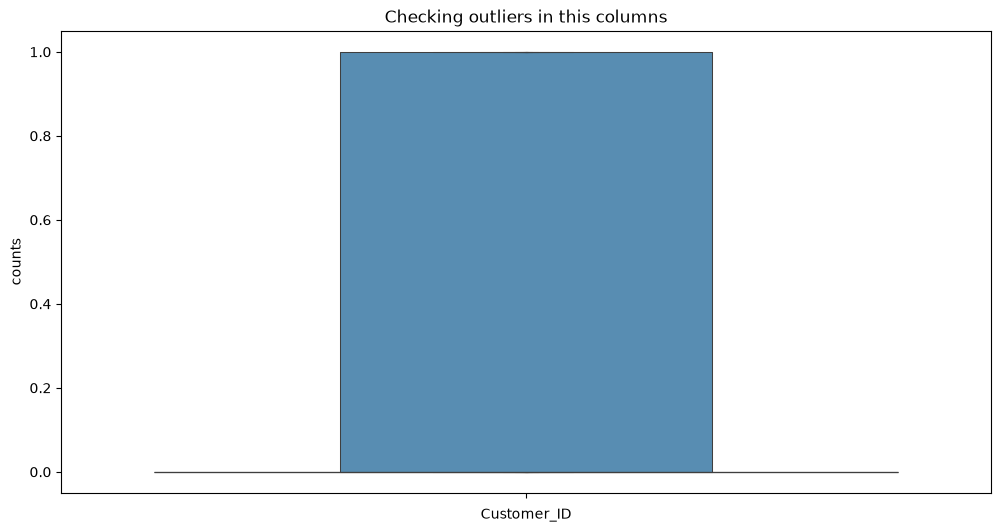

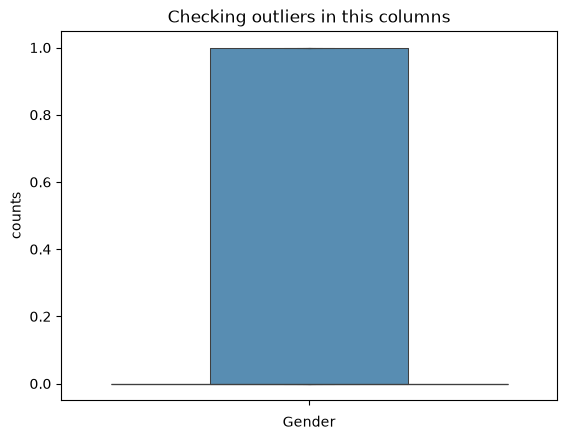

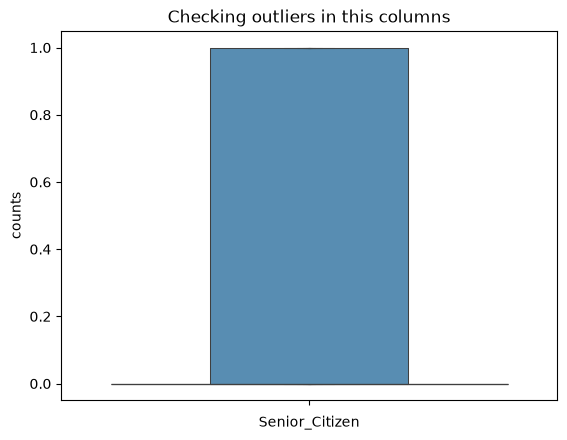

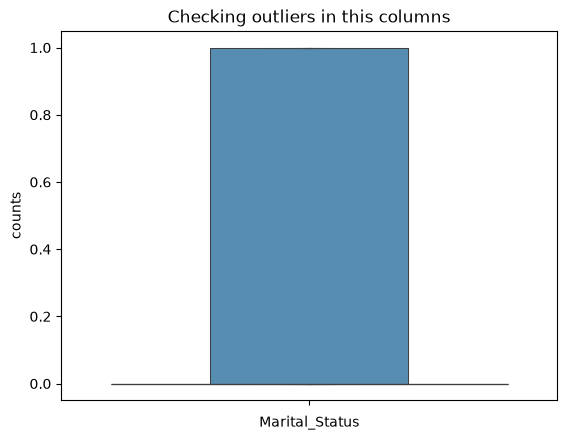

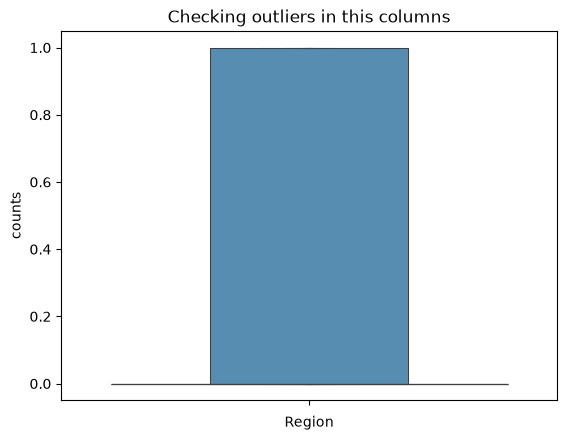

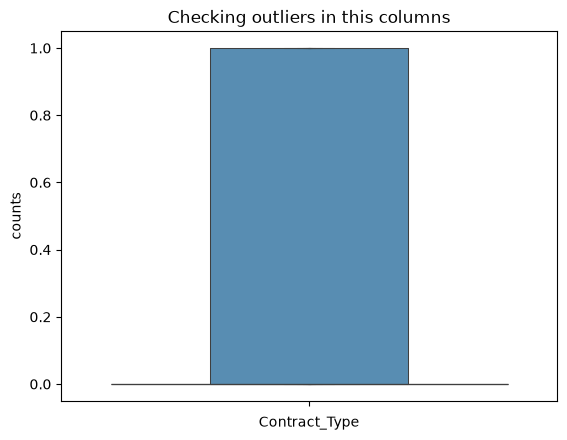

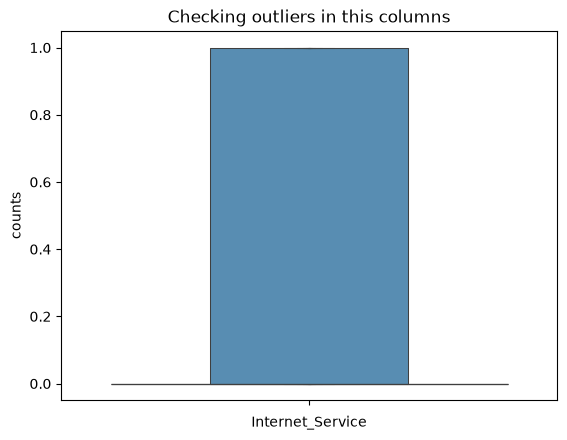

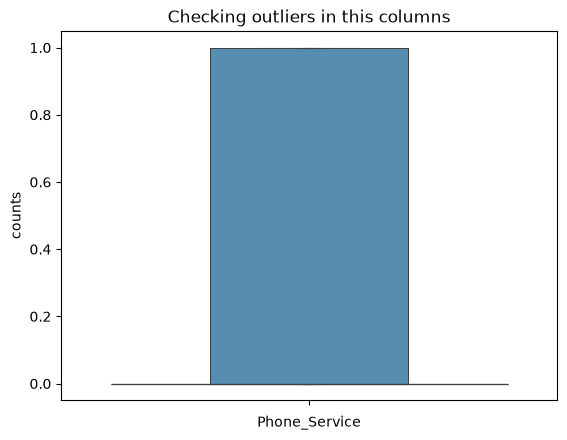

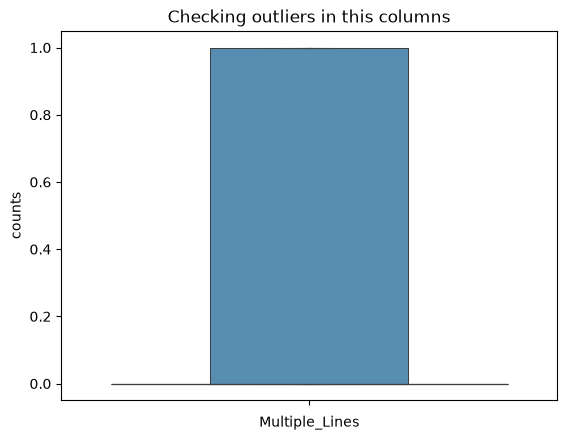

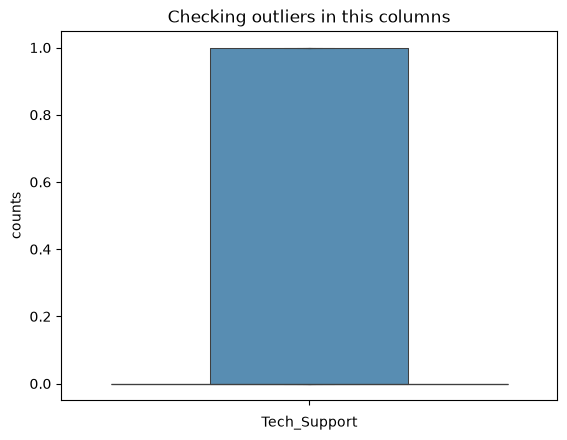

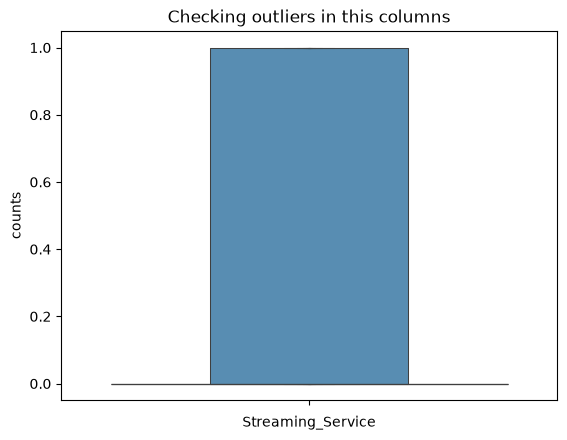

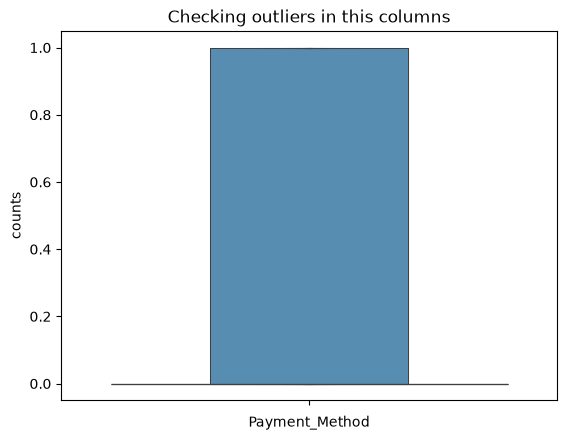

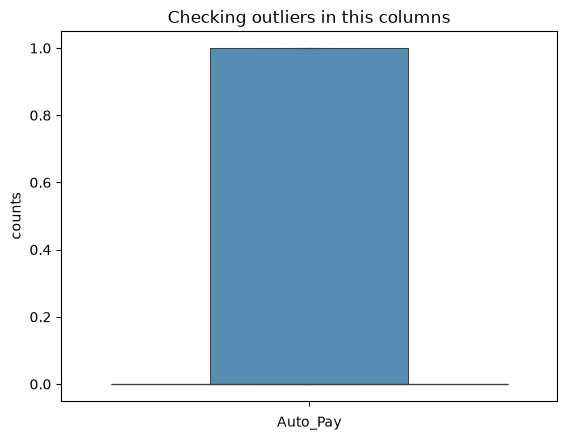

In [74]:
plt.figure(figsize=(12,6))
for feature in categorical_columns:
    sns.boxenplot(df[i])
    plt.xlabel(feature)
    plt.ylabel("counts")
    plt.title("Checking outliers in this columns")
    plt.show()

## Observation:
In categorical columns we have a no outliers

# CHECKING INCONSISTENT VALUE IN CATEGORICAL COLUMNS

In [78]:
for col in categorical_columns:
    print(f"\n--- {col} ---")
    print("Unique values:", df[col].nunique())
    print(df[col].unique())


--- Customer_ID ---
Unique values: 100000
<ArrowStringArray>
['CUST000001', 'CUST000002', 'CUST000003', 'CUST000004', 'CUST000005',
 'CUST000006', 'CUST000007', 'CUST000008', 'CUST000009', 'CUST000010',
 ...
 'CUST099991', 'CUST099992', 'CUST099993', 'CUST099994', 'CUST099995',
 'CUST099996', 'CUST099997', 'CUST099998', 'CUST099999', 'CUST100000']
Length: 100000, dtype: str

--- Gender ---
Unique values: 2
<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

--- Senior_Citizen ---
Unique values: 2
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

--- Marital_Status ---
Unique values: 3
<ArrowStringArray>
['Divorced', 'Married', 'Single']
Length: 3, dtype: str

--- Region ---
Unique values: 5
<ArrowStringArray>
['South', 'North', 'West', 'Central', 'East']
Length: 5, dtype: str

--- Contract_Type ---
Unique values: 3
<ArrowStringArray>
['Two Year', 'Month-to-Month', 'One Year']
Length: 3, dtype: str

--- Internet_Service ---
Unique values: 3
<ArrowStringArray>
[nan, 'Fibe

## Observation:
In this categorical feature we have no inconsistent values

## FINDING USEFULL INSIGHT IN CATEGORICAL COLUMNS

In [79]:
categorical_columns.head(2)

,Customer_ID,Gender,Senior_Citizen,Marital_Status,Region,Contract_Type,Internet_Service,Phone_Service,Multiple_Lines,Tech_Support,Streaming_Service,Payment_Method,Auto_Pay
0,CUST000001,Male,Yes,Divorced,South,Two Year,NaN,Yes,No,Yes,No,Credit Card,No
1,CUST000002,Female,Yes,Divorced,North,Month-to-Month,Fiber,Yes,No,No,Yes,Debit Card,Yes


In [80]:
pd.crosstab(df['Gender'],df['Churn'])

Churn,0,1
Gender,,
Female,37664,12369
Male,37440,12527


## Observation
BOTH GENDER NOT CHURN RIST ALMOST SIMMILER

BOTH GENDER CHURN RIST ALMOST SIMMILER

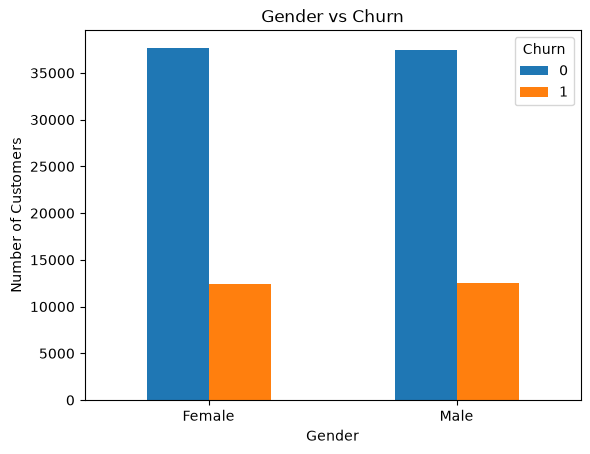

In [81]:
pd.crosstab(
    df['Gender'],
    df['Churn']
).plot.bar()

plt.title('Gender vs Churn')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [82]:
pd.crosstab(df['Senior_Citizen'],df['Churn'])

Churn,0,1
Senior_Citizen,,
No,37294,12373
Yes,37810,12523


## Observation
IF THE PERSON SENIOR_CITIZEN AND IF THE PERSON  NOT SENIOR_CITIZEN BOTH NOT CHURN RIST AND CHURN RISK SAME

<Figure size 1200x600 with 0 Axes>

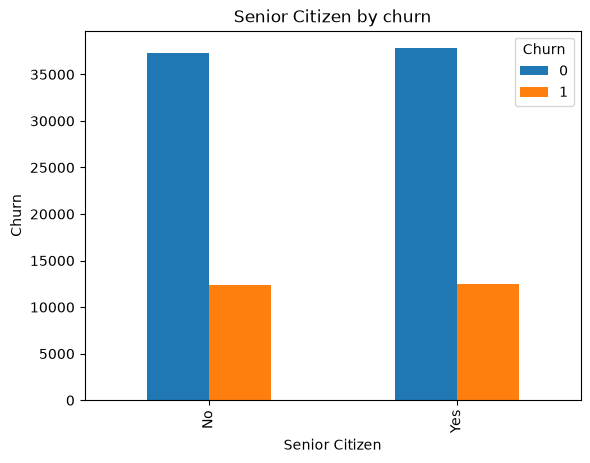

In [83]:
plt.figure(figsize=(12,6))
pd.crosstab(
    df['Senior_Citizen'],
    df['Churn']
).plot.bar()
plt.xlabel('Senior Citizen')
plt.ylabel("Churn")
plt.title("Senior Citizen by churn")
plt.show()

In [86]:
pd.crosstab(df['Marital_Status'], df['Churn'],normalize='index')

Churn,0,1
Marital_Status,,
Divorced,0.754833,0.245167
Married,0.746382,0.253618
Single,0.751902,0.248098


## Observation
if the person marital status divorced or married or single not churn risk almost simmler and chrn risk also same

<Figure size 1200x600 with 0 Axes>

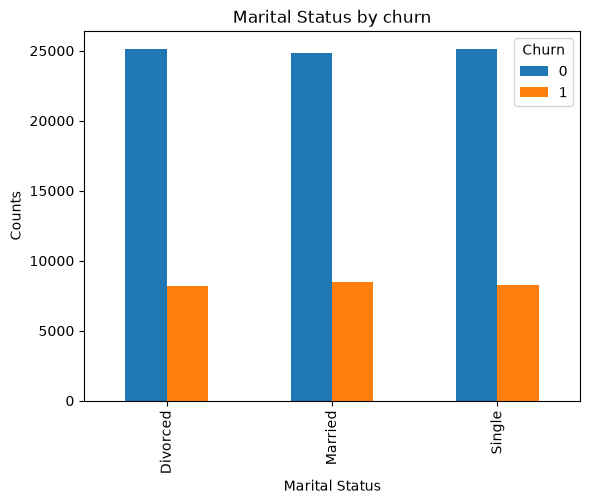

In [87]:
plt.figure(figsize=(12,6))
pd.crosstab(
    df['Marital_Status'],
    df['Churn']
).plot.bar()
plt.xlabel('Marital Status')
plt.ylabel("Counts")
plt.title('Marital Status by churn')
plt.show()

In [89]:
pd.crosstab(df['Region'],df['Churn'])

Churn,0,1
Region,,
Central,14933,4972
East,15024,5008
North,14944,4977
South,15153,4891
West,15050,5048


### Observation

* **Churn is relatively consistent across all regions**, with no major regional difference.
* **West** has the highest number of churned customers (**5,048**).
* **South** has the lowest number of churned customers (**4,891**).
* **East** has the highest number of non-churned customers (**15,024**), while **South** has the highest overall non-churned count (**15,153**)—so the key takeaway is that the non-churned group is broadly similar across regions.
* Overall, **Region does not appear to have a strong influence on churn**, as the churn counts are fairly close across all five regions.

**EDA conclusion:**

> *Churn behavior is broadly similar across regions, suggesting that Region alone may not be a strong predictor of customer churn.*


<Figure size 1200x600 with 0 Axes>

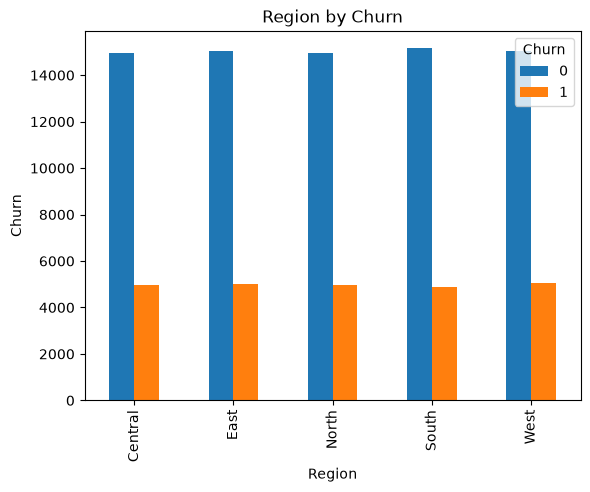

In [91]:
plt.figure(figsize=(12,6))
pd.crosstab(
    df['Region'],
    df['Churn']
).plot.bar()
plt.xlabel('Region')
plt.ylabel('Churn')
plt.title('Region by Churn')
plt.show()

In [94]:
pd.crosstab(
    df['Contract_Type'],
    df['Churn']
)

Churn,0,1
Contract_Type,,
Month-to-Month,37424,17569
One Year,20884,4107
Two Year,16796,3220


## Observaion:
IF THE CUSTOMER CONTRACT TYPE IS MONTH TO MONTH THE NOT CHURN RISK AROUND(37424) AND CHURN CUSTOMER AROUND(17569) NOT CHURN > CURN

IF THE CUSTOMER CONTRACT TYPE IS ONE YEAR NOT CHURN RISK AROUND(20884) AND CHURN RISK AROUND(4107) NOT CHURN > CHURN

IF THE CUSTOMER CONTRACT TYPE IS TWO YEAR NOT CHURN RISK AROUND(16796) AND CHURN RIST AROUND(3220) NOT CHURN > CURN